In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# from ultralytics.data.converter import convert_coco

# # Вкажіть шлях до папки, де лежить ваш result.json
# convert_coco(labels_dir='./dataset/', use_segments=True)

In [3]:
# import json

# with open('dataset/result_coco.json', 'r') as f:
#     data = json.load(f)

# for image in data['images']:
#     # Прибираємо шлях і залишаємо тільки назву файлу
#     full_name = image['file_name']
#     image['file_name'] = full_name.split('/')[-1].split('_', 1)[-1] 

# with open('result_fixed.json', 'w') as f:
#     json.dump(data, f)

In [4]:
# import os

# # 1. Вкажіть шлях до папки з вашими файлами (labels або images)
# folder_path = r'C:\UnProg\DIPLOMA\coco_converted2\labels\result_coco' 

# # 2. Виберіть роздільник (зазвичай '_' для Label Studio)
# separator = '-' 

# files = os.listdir(folder_path)
# count = 0

# for filename in files:
#     if separator in filename:
#         # Розбиваємо назву на дві частини по ПЕРШОМУ роздільнику
#         # '8b2a1_my_image.txt' -> ['8b2a1', 'my_image.txt']
#         new_name = filename.split(separator, 1)[-1]
        
#         old_path = os.path.join(folder_path, filename)
#         new_path = os.path.join(folder_path, new_name)
        
#         # Перевіряємо, чи такий файл уже не існує, щоб не перезаписати його
#         if not os.path.exists(new_path):
#             os.rename(old_path, new_path)
#             count += 1
#         else:
#             print(f"Пропущено: {new_name} вже існує")

# print(f"Готово! Перейменовано файлів: {count}")

In [5]:
# from ultralytics import YOLO

# model = YOLO("yolo26n-seg.pt")

# # Вказуємо шлях до вашого YAML файлу
# model.train(
#     data="sfx_data.yaml", 
#     epochs=50, 
#     imgsz=640,
#     workers=0
# )

In [6]:
from ultralytics import YOLO

model = YOLO("runs/segment/train7/weights/best.pt")


image 1/1 c:\UnProg\DIPLOMA\imgs\5.jpg: 512x640 4 sfxs, 167.6ms
Speed: 2.5ms preprocess, 167.6ms inference, 4.9ms postprocess per image at shape (1, 3, 512, 640)


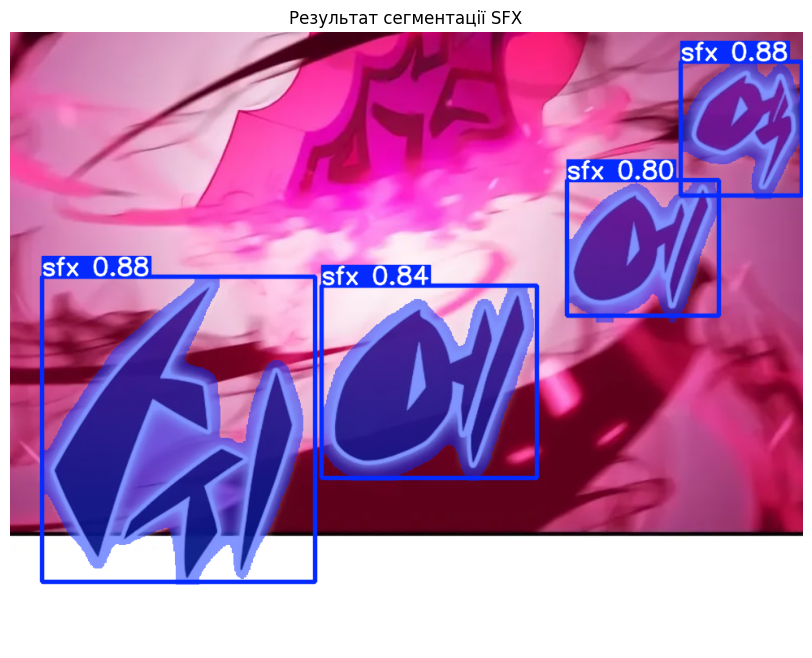

In [15]:
import matplotlib.pyplot as plt
import cv2

# 2. Отримуємо результат
results = model.predict(source="imgs/5.jpg", conf=0.25)
res = results[0]

# 3. Побудова зображення з масками (у форматі BGR)
plot_bgr = res.plot() 

# 4. Конвертуємо BGR в RGB для Matplotlib
plot_rgb = cv2.cvtColor(plot_bgr, cv2.COLOR_BGR2RGB)

# 5. Візуалізація
plt.figure(figsize=(12, 8))
plt.imshow(plot_rgb)
plt.axis('off') # прибрати координатні осі
plt.title("Результат сегментації SFX")
plt.show()

In [16]:
import numpy as np
import torch

# 1. Перевіряємо, чи є маски у результаті
if res.masks is not None:
    # Отримуємо всі маски як один тензор і об'єднуємо їх (логічне "АБО")
    # Маски зазвичай мають менший розмір, ніж оригінал, тому використовуємо .xy для точного розміру
    combined_mask = torch.any(res.masks.data, dim=0).cpu().numpy()

    # 2. Масштабуємо маску до розміру оригінального зображення
    # YOLO зберігає маски у внутрішньому розширенні, тому треба розтягнути до imgs/5.jpg
    orig_h, orig_w = res.orig_shape
    mask_resized = cv2.resize(combined_mask.astype(np.uint8), (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # 3. Перетворюємо в формат 0-255 (білий - область для зміни, чорний - залишити)
    bw_mask = (mask_resized * 255).astype(np.uint8)

    # 4. Збереження
    cv2.imwrite("inpaint_mask.png", bw_mask)
    
    print("Маску збережено як inpaint_mask.png")
else:
    print("Об'єктів для маскування не знайдено.")

Маску збережено як inpaint_mask.png


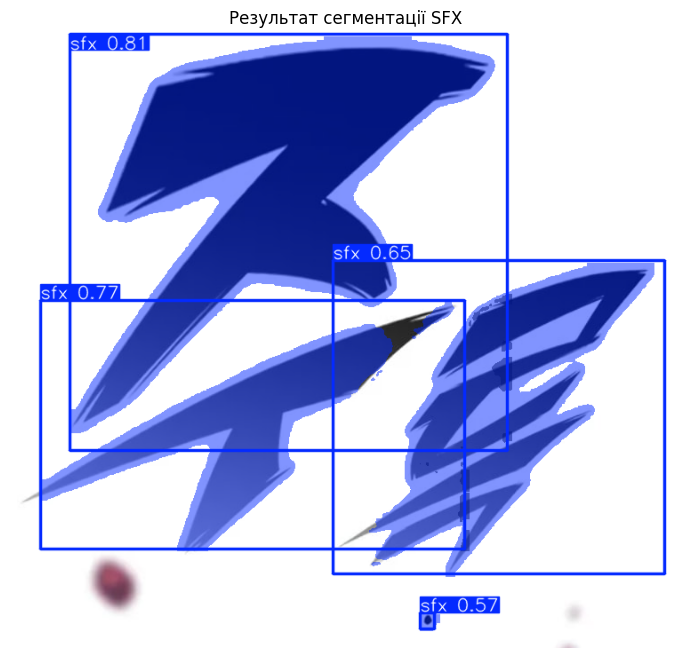

In [9]:
plt.figure(figsize=(12, 8))
plt.imshow(plot_rgb)
plt.axis('off') # прибрати координатні осі
plt.title("Результат сегментації SFX")
plt.show()

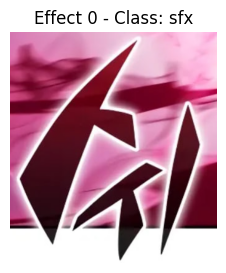

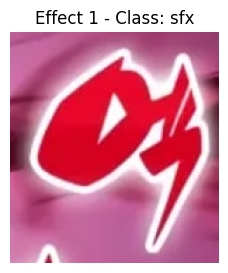

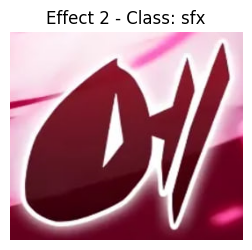

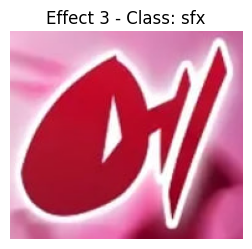

In [20]:
import cv2
import matplotlib.pyplot as plt

img = res.orig_img  # Оригінальне зображення

# Проходимо по всіх знайдених боксах
for i, box in enumerate(res.boxes):
    # Отримуємо координати (x1, y1, x2, y2)
    xyxy = box.xyxy[0].cpu().numpy().astype(int)
    x1, y1, x2, y2 = xyxy
    
    # Обрізаємо зображення по координатах
    crop = img[y1:y2, x1:x2]
    
    # Відображаємо
    plt.figure(figsize=(3, 3))
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.title(f"Effect {i} - Class: {res.names[int(box.cls[0])]}")
    plt.axis('off')
    plt.show()

In [21]:
results[0].save_crop(save_dir='exported_effects')